# ✅ Solutions — Module 7 — ANOVA, Rank-Based Tests & Categorical Data

Worked solutions for every exercise of this module. **Try the exercise yourself first** — you learn statistics by *doing* it. Each solution ends with a short interpretation, because in real projects the numbers are only half of the answer.

*Every exercise is self-contained: run the setup cell below, then jump to any exercise.*

In [1]:
# --- Course setup (identical in every module) ---
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 4.2), "figure.dpi": 90, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
C = sns.color_palette("deep")      # C[0] blue, C[1] orange, C[2] green, C[3] red, C[4] purple
rng = np.random.default_rng(42)    # seeded generator => reproducible results

# --- additional tools for this module ---
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd

### ✍️ Exercise 7.1 — *One-way ANOVA & Tukey HSD*: Which fertiliser blend should the cooperative buy? (Agriculture)

An agricultural cooperative tests three fertiliser blends against a control on 40 comparable wheat plots (10 per treatment, randomly assigned). Blend C is 20 % cheaper than blend B.

**Tasks**
1. Plot the yields per treatment.
2. Run a one-way ANOVA and compute $\eta^2$.
3. Check the assumptions (Levene's test; normality of the residuals).
4. Run Tukey's HSD. Which treatments differ?
5. Which blend do you recommend, and why?

In [2]:
g = np.random.default_rng(737)
true_means = {"control": 5.2, "blend A": 5.5, "blend B": 6.3, "blend C": 6.1}                 # t/ha — unknown to the analyst
wheat = pd.DataFrame([(b, y) for b, mu in true_means.items() for y in g.normal(mu, .55, 10).round(2)], columns=["fertiliser", "yield_t_ha"])
wheat.groupby("fertiliser", sort=False).yield_t_ha.agg(["mean", "std"]).round(2)

,mean,std
fertiliser,,
control,5.27,0.53
blend A,5.62,0.64
blend B,6.51,0.38
blend C,6.26,0.65


ANOVA: F = 10.32, p = 0.00005, eta² = 0.46
Levene (equal variances): p = 0.718;  Shapiro–Wilk on residuals: p = 0.835


 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
blend A blend B     0.89 0.0058  0.2145  1.5655   True
blend A blend C    0.637 0.0705 -0.0385  1.3125  False
blend A control    -0.35 0.5103 -1.0255  0.3255  False
blend B blend C   -0.253 0.7453 -0.9285  0.4225  False
blend B control    -1.24 0.0001 -1.9155 -0.5645   True
blend C control   -0.987  0.002 -1.6625 -0.3115   True
------------------------------------------------------


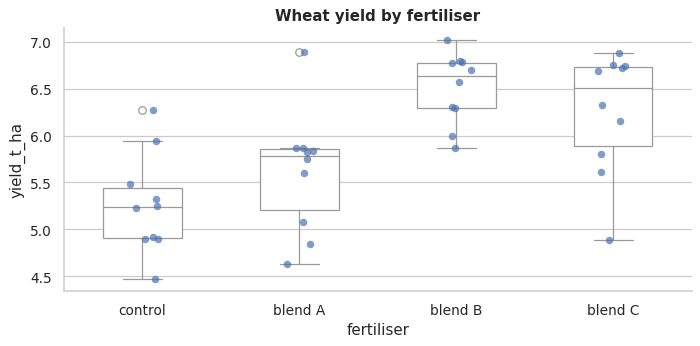

In [3]:
samples = [grp.yield_t_ha.values for _, grp in wheat.groupby("fertiliser", sort=False)]
F, p = stats.f_oneway(*samples)
grand = wheat.yield_t_ha.mean(); group_mean = wheat.groupby("fertiliser").yield_t_ha.transform("mean")
eta2 = ((group_mean - grand) ** 2).sum() / ((wheat.yield_t_ha - grand) ** 2).sum()
resid = wheat.yield_t_ha - group_mean
print(f"ANOVA: F = {F:.2f}, p = {p:.5f}, eta² = {eta2:.2f}")
print(f"Levene (equal variances): p = {stats.levene(*samples).pvalue:.3f};  Shapiro–Wilk on residuals: p = {stats.shapiro(resid).pvalue:.3f}")
print(pairwise_tukeyhsd(wheat.yield_t_ha, wheat.fertiliser).summary())

fig, ax = plt.subplots(figsize=(9, 3.8))
sns.boxplot(wheat, x="fertiliser", y="yield_t_ha", color="white", width=.5, ax=ax); sns.stripplot(wheat, x="fertiliser", y="yield_t_ha", color=C[0], size=6, alpha=.7, ax=ax)
ax.set_title("Wheat yield by fertiliser"); plt.show()

**Interpretation.** The global test is clearly significant and fertiliser explains a large share of the yield variation ($\eta^2 \approx 0.46$: almost half of it). Levene and Shapiro–Wilk give no reason to distrust the ANOVA. Tukey's HSD shows the typical cluster pattern: blends **B and C beat the control**, while **B vs. C** is not significant — their interval comfortably includes zero. Blend A cannot be distinguished from the control.

**Recommendation:** buy **blend C**. It performs on par with B within the precision of this trial and costs 20 % less. Note the careful wording — "no significant difference" is not proof of equality; the Tukey interval for B − C tells the cooperative how large a disadvantage of C is still plausible, and they can judge whether that is worth 20 % of the price.

### ✍️ Exercise 7.2 — *Two-way ANOVA & interaction*: Where does the discount pay off? (Marketing)

A retailer ran a 3 × 3 campaign experiment: three **channels** (e-mail, social, search) crossed with three **discount levels** (0 %, 10 %, 20 %), 30 customers per cell. Outcome: revenue per customer (€).

**Tasks**
1. Draw an interaction plot (discount on the x-axis, one line per channel).
2. Fit the two-way ANOVA with interaction and print the type-II table.
3. Is there an interaction? What does it mean in business terms?
4. Compute the cell means. For which channel does the step from 10 % to 20 % discount bring the most?

In [4]:
g = np.random.default_rng(702)
rows = []
for ch, base in {"e-mail": 40, "social": 34, "search": 46}.items():
    for disc, lift in {"0 %": 0, "10 %": 6, "20 %": 9}.items():
        extra = 8 if (ch == "social" and disc == "20 %") else 0
        rows += [(ch, disc, v) for v in g.normal(base + lift + extra, 9, 30).round(1)]
camp = pd.DataFrame(rows, columns=["channel", "discount", "revenue"])
camp.head()

,channel,discount,revenue
0,e-mail,0 %,31.6
1,e-mail,0 %,31.5
2,e-mail,0 %,50.8
3,e-mail,0 %,21.6
4,e-mail,0 %,46.5


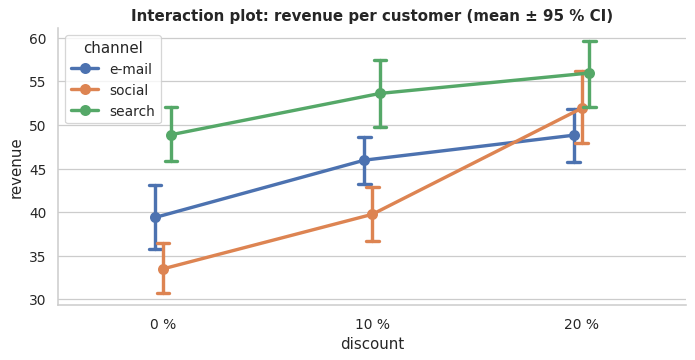

                      sum_sq     df        F  PR(>F)
channel            5929.6650    2.0  31.3259  0.0000
discount           6094.7801    2.0  32.1982  0.0000
channel:discount   1342.7035    4.0   3.5467  0.0077
Residual          24702.2797  261.0      NaN     NaN

cell means (€):
discount   0 %  10 %  20 %  gain 10→20 %
channel                                 
e-mail    39.4  46.0  48.8           2.8
search    48.9  53.6  56.0           2.4
social    33.5  39.8  51.9          12.1


In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.pointplot(data=camp, x="discount", y="revenue", hue="channel", dodge=True, capsize=.06, ax=ax, palette=[C[0], C[1], C[2]])
ax.set_title("Interaction plot: revenue per customer (mean ± 95 % CI)"); plt.show()

model = smf.ols("revenue ~ channel * discount", data=camp).fit()
print(sm.stats.anova_lm(model, typ=2).round(4))
cell = camp.pivot_table(index="channel", columns="discount", values="revenue", aggfunc="mean").round(1)
cell["gain 10→20 %"] = (cell["20 %"] - cell["10 %"]).round(1)
print("\ncell means (€):"); print(cell)

**Interpretation.** Both main effects are significant: channels differ in baseline revenue (search > e-mail > social) and discounts raise revenue. The **interaction** is significant too — the lines are not parallel: on e-mail and search the step from 10 % to 20 % adds only a few euros, whereas on **social** it adds far more.

**Business meaning:** "the effect of a 20 % discount" is not one number. A deep discount pays off on social media (perhaps because offers are shared), but on search and e-mail the extra 10 percentage points of margin buy almost nothing. A one-factor-at-a-time experiment would have missed this completely — that is the case for **factorial designs**.

### ✍️ Exercise 7.3 — *Mann–Whitney U*: Did the app redesign improve ratings? (Product analytics)

Star ratings (1–5) were collected for the old and the redesigned version of a mobile app. Ratings are **ordinal** — the distance between 1★ and 2★ need not equal the distance between 4★ and 5★ — so comparing means is questionable.

**Tasks**
1. Plot the two rating distributions as percentages.
2. Run a Mann–Whitney $U$ test.
3. Compute the **probability of superiority** $U/(n_1 n_2)$ and interpret it.
4. Summarise the result for the product team in one sentence.

In [6]:
g = np.random.default_rng(703)
old = g.choice(np.arange(1, 6), 180, p=[.12, .13, .25, .30, .20])
new = g.choice(np.arange(1, 6), 165, p=[.07, .09, .20, .34, .30])
print("old:", np.bincount(old)[1:], " new:", np.bincount(new)[1:], " (counts for 1★ … 5★)")

old: [22 27 43 53 35]  new: [ 7  8 46 56 48]  (counts for 1★ … 5★)


Mann–Whitney U = 18040, p = 0.0004
probability of superiority P(new > old) + ½P(tie) = 0.607
medians: old 3★, new 4★;   share of 4–5★: old 49%, new 63%


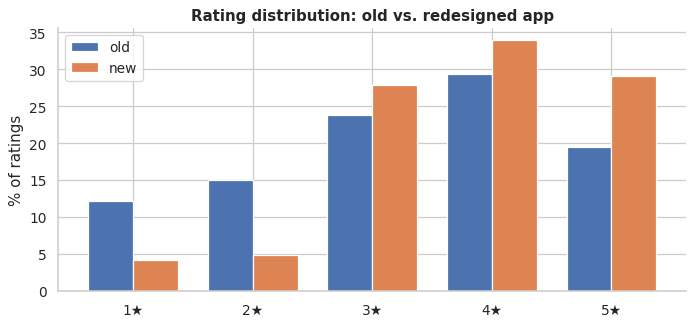

In [7]:
res = stats.mannwhitneyu(new, old, alternative="two-sided")
ps = res.statistic / (new.size * old.size)
print(f"Mann–Whitney U = {res.statistic:.0f}, p = {res.pvalue:.4f}")
print(f"probability of superiority P(new > old) + ½P(tie) = {ps:.3f}")
print(f"medians: old {np.median(old):.0f}★, new {np.median(new):.0f}★;   share of 4–5★: old {(old >= 4).mean():.0%}, new {(new >= 4).mean():.0%}")

share = pd.DataFrame({"old": np.bincount(old, minlength=6)[1:] / old.size, "new": np.bincount(new, minlength=6)[1:] / new.size}, index=[f"{s}★" for s in range(1, 6)]) * 100
ax = share.plot.bar(figsize=(9, 3.8), color=[C[0], C[1]], rot=0, width=.75); ax.set(ylabel="% of ratings", title="Rating distribution: old vs. redesigned app"); plt.show()

**Interpretation.** The whole distribution has shifted towards higher ratings: fewer 1–3★, more 4–5★. The Mann–Whitney test confirms that this shift is unlikely to be chance. The probability of superiority (≈ 0.61) has a concrete reading: *pick one random rating of the new version and one of the old version — in about 6 of 10 such pairs the new version wins (ties split evenly).*

**One-sentence summary:** "The redesign shifted ratings upwards (share of 4–5★ ratings up from 49 % to 63 %; Mann–Whitney p < 0.001); a randomly chosen new-version rating beats an old-version rating about 61 % of the time."

### ✍️ Exercise 7.4 — *χ² goodness of fit*: Benford's law and suspicious expense claims (Forensic accounting)

In many naturally occurring sets of amounts that span several orders of magnitude, the first digit $d$ appears with probability $\log_{10}(1+1/d)$ — **Benford's law** (30.1 % start with 1, only 4.6 % with 9). Fabricated numbers usually violate it, which is why auditors and tax authorities use it as a screening tool.

An internal auditor examines 840 expense claims. Claims below €1,000 need no second approval.

**Tasks**
1. Tabulate the first digits and compare them with Benford's expected counts.
2. Run a $\chi^2$ goodness-of-fit test.
3. Plot observed vs. expected and compute each digit's standardised residual. Which digits are over-represented?
4. What is a plausible story — and what would you do next? Is a Benford deviation proof of fraud?

In [8]:
g = np.random.default_rng(704)
amounts = np.concatenate([g.lognormal(5.5, 1.4, 700), g.uniform(400, 990, 140)]).round(2)     # claim amounts in €
first_digit = np.array([int(f"{a:e}"[0]) for a in amounts])                                   # scientific notation -> leading digit
print(amounts[:8], first_digit[:8])

[ 208.29   65.61  409.02 5490.46  125.65  612.73  129.58 4750.9 ] [2 6 4 5 1 6 1 4]


                   1      2      3     4     5     6     7     8     9
observed       181.0  128.0   94.0  95.0  93.0  64.0  58.0  59.0  68.0
expected       252.9  147.9  104.9  81.4  66.5  56.2  48.7  43.0  38.4
std. residual   -4.5   -1.6   -1.1   1.5   3.2   1.0   1.3   2.4   4.8

chi2 = 68.6, df = 8, p = 9.20e-12


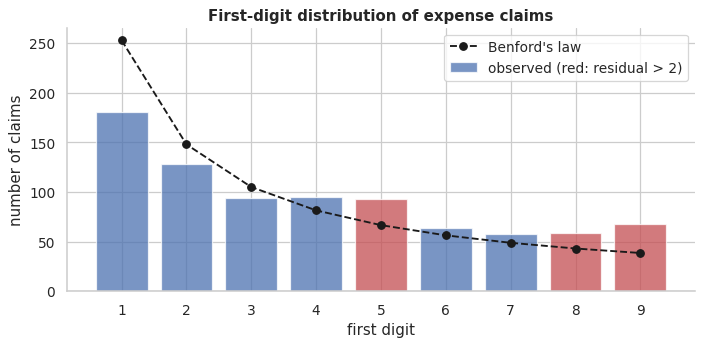

In [9]:
digits = np.arange(1, 10)
observed = np.array([(first_digit == d).sum() for d in digits])
benford = np.log10(1 + 1 / digits); expected = benford * observed.sum()
chi2, p = stats.chisquare(observed, expected)
resid = (observed - expected) / np.sqrt(expected)
print(pd.DataFrame({"observed": observed, "expected": expected.round(1), "std. residual": resid.round(1)}, index=digits).T)
print(f"\nchi2 = {chi2:.1f}, df = 8, p = {p:.2e}")

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar(digits, observed, color=[C[3] if r > 2 else C[0] for r in resid], alpha=.75, label="observed (red: residual > 2)")
ax.plot(digits, expected, "ko--", label="Benford's law"); ax.set(xticks=digits, xlabel="first digit", ylabel="number of claims", title="First-digit distribution of expense claims"); ax.legend(); plt.show()

**Interpretation.** The claims deviate massively from Benford's law ($p$ practically zero). The residuals show *where*: first digits 4 to 9 are all over-represented (most clearly 5, 8 and 9), digit 1 is strongly under-represented. A natural explanation is a cluster of amounts **just below the €1,000 approval threshold** (400–990 €) — either legitimate behaviour (people bundle purchases to stay below the limit) or invented claims designed to avoid scrutiny.

**Next steps:** pull the claims between €400 and €999 and look at them by employee, by date and by vendor; check for round numbers and duplicates.

**Caveat:** a Benford deviation is a **red flag, not a proof**. Data with a built-in range (prices of one product, body heights) never follow Benford. The test tells you where to look — the judgement needs an auditor.

### ✍️ Exercise 7.5 — *χ² test of independence*: Is the chosen subscription plan related to age? (Market research)

A streaming provider surveyed 1,000 subscribers about their plan (Basic / Standard / Premium) and age group.

**Tasks**
1. Build the contingency table and the row percentages.
2. Test independence; verify that all expected counts are ≥ 5.
3. Compute Cramér's $V$.
4. Plot the standardised residuals. Which age groups over- or under-index on which plan?
5. One actionable marketing insight, please.

In [10]:
g = np.random.default_rng(705)
plans = ["Basic", "Standard", "Premium"]
probs = {"18–29": [.55, .33, .12], "30–44": [.35, .42, .23], "45–59": [.30, .42, .28], "60+": [.45, .40, .15]}
survey = pd.DataFrame([(a, pl) for (a, pr), n in zip(probs.items(), [220, 310, 270, 200]) for pl in g.choice(plans, n, p=pr)], columns=["age_group", "plan"])
survey.sample(5, random_state=1)

,age_group,plan
507,30–44,Premium
818,60+,Premium
452,30–44,Standard
368,30–44,Premium
242,30–44,Standard


plan       Basic  Standard  Premium
age_group                          
18–29        117        83       20
30–44        108       139       63
45–59         84       120       66
60+           81        83       36 

row percentages:
 plan       Basic  Standard  Premium
age_group                          
18–29       53.2      37.7      9.1
30–44       34.8      44.8     20.3
45–59       31.1      44.4     24.4
60+         40.5      41.5     18.0

chi2 = 35.3, df = 6, p = 3.80e-06;  smallest expected count = 37.0;  Cramér's V = 0.13


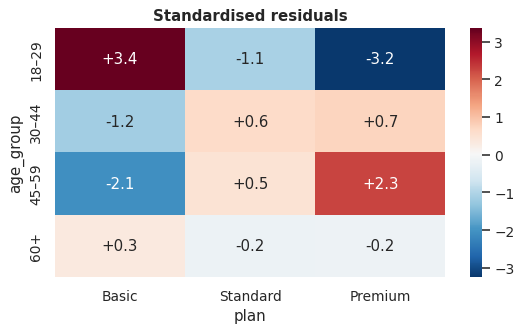

In [11]:
tab = pd.crosstab(survey.age_group, survey.plan)[plans]
chi2, p, dof, exp = stats.chi2_contingency(tab)
V = np.sqrt(chi2 / (tab.values.sum() * (min(tab.shape) - 1)))
resid = (tab - exp) / np.sqrt(exp)
print(tab, "\n\nrow percentages:\n", (tab.div(tab.sum(axis=1), axis=0) * 100).round(1))
print(f"\nchi2 = {chi2:.1f}, df = {dof}, p = {p:.2e};  smallest expected count = {exp.min():.1f};  Cramér's V = {V:.2f}")
fig, ax = plt.subplots(figsize=(7, 3.6))
sns.heatmap(resid, annot=True, fmt="+.1f", cmap="RdBu_r", center=0, ax=ax); ax.set_title("Standardised residuals"); plt.show()

**Interpretation.** Plan choice and age are clearly dependent (tiny p-value, all expected counts far above 5), but the association is **weak** (Cramér's $V \approx 0.13$) — with $n = 1{,}000$ even modest associations are highly significant. The residuals show the structure: the **youngest** group over-indexes on *Basic* and strongly under-indexes on *Premium*; the **middle** age groups (30–59) over-index on *Premium*; the 60+ group sits close to the overall average.

**Marketing insight:** Premium upsell campaigns should target the 30–59 segment, where appetite already exists; for the under-30s price is the barrier, so a student discount or an ad-supported tier is more promising than a Premium push.

### ✍️ Exercise 7.6 — *Fisher's exact test, RR, OR, NNT*: A small migraine trial (Clinical research)

In a pilot trial, 43 migraine patients were randomised. Two hours after taking the medication, **14 of 22** patients on the new drug and **6 of 21** on placebo were pain-free.

**Tasks**
1. Build the 2×2 table and check the expected counts. Is the $\chi^2$ approximation comfortable?
2. Run Fisher's exact test.
3. Compute risk difference, NNT ("number needed to treat"), relative "risk" of being pain-free and the odds ratio, with 95 % CIs for RR and OR.
4. Why is the OR so much larger than the RR here? Which one would you communicate to patients?

In [12]:
table = pd.DataFrame([[14, 8], [6, 15]], index=["new drug", "placebo"], columns=["pain-free", "not pain-free"])
table

,pain-free,not pain-free
new drug,14,8
placebo,6,15


expected counts:
 [[10.2 11.8]
 [ 9.8 11.2]]

Fisher's exact test: p = 0.0329   (chi-square with continuity correction: p = 0.0457)
pain-free: 63.6% vs 28.6%  ->  RD = +35.1%,  NNT = 2.9
RR = 2.23  (95 % CI 1.06 – 4.70)
OR = 4.38  (95 % CI 1.21 – 15.81)


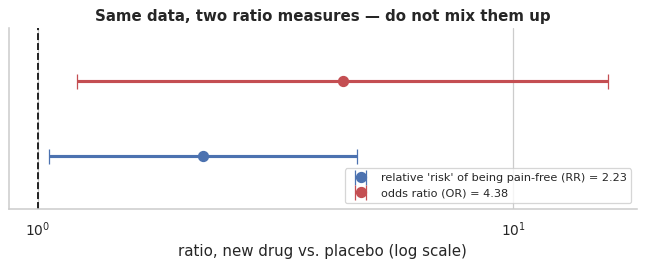

In [13]:
(a, b), (c, d) = table.values
exp = stats.chi2_contingency(table)[3]
odds, p_fisher = stats.fisher_exact(table)
p1, p2 = a / (a + b), c / (c + d); rd = p1 - p2
rr, se_rr = p1 / p2, np.sqrt(1 / a - 1 / (a + b) + 1 / c - 1 / (c + d))
orr, se_or = a * d / (b * c), np.sqrt(1 / a + 1 / b + 1 / c + 1 / d)
print("expected counts:\n", exp.round(1))
print(f"\nFisher's exact test: p = {p_fisher:.4f}   (chi-square with continuity correction: p = {stats.chi2_contingency(table)[1]:.4f})")
print(f"pain-free: {p1:.1%} vs {p2:.1%}  ->  RD = {rd:+.1%},  NNT = {1 / rd:.1f}")
print(f"RR = {rr:.2f}  (95 % CI {rr * np.exp(-1.96 * se_rr):.2f} – {rr * np.exp(1.96 * se_rr):.2f})")
print(f"OR = {orr:.2f}  (95 % CI {orr * np.exp(-1.96 * se_or):.2f} – {orr * np.exp(1.96 * se_or):.2f})")
fig, ax = plt.subplots(figsize=(9, 2.6))
for i, (name, est, se) in enumerate([("relative 'risk' of being pain-free (RR)", rr, se_rr), ("odds ratio (OR)", orr, se_or)]):
    ax.errorbar([est], [i], xerr=[[est - est * np.exp(-1.96 * se)], [est * np.exp(1.96 * se) - est]], fmt="o", color=[C[0], C[3]][i], capsize=6, lw=2.5, ms=8, label=f"{name} = {est:.2f}")
ax.axvline(1, color="k", ls="--"); ax.set(xscale="log", yticks=[], ylim=(-.7, 1.7), xlabel="ratio, new drug vs. placebo (log scale)", title="Same data, two ratio measures — do not mix them up"); ax.legend(loc="lower right", fontsize=9); plt.show()

**Interpretation.** 64 % vs. 29 % pain-free: an absolute gain of 35 percentage points, i.e. **NNT ≈ 3** — treat three patients and one additional patient becomes pain-free, a strong effect for a migraine drug. Fisher's exact test gives $p \approx 0.03$–$0.04$; the expected counts (≈ 10) would have allowed $\chi^2$ as well, but with 43 patients the exact test is the safe choice. The intervals are wide (RR roughly 1.1 to 4.7): the pilot shows the drug works, not precisely how well.

**OR vs. RR:** the event is *common* here (29–64 %), and then the odds ratio (≈ 4.4) greatly exceeds the relative risk (≈ 2.2). Reading an OR as if it were an RR — "four times as likely" — is a classic blunder. For patients, communicate **absolute numbers**: "about 6 of 10 instead of 3 of 10 patients are pain-free after two hours."